In [5]:
import tensorflow as tf
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

In [30]:
# Physical parameters
rho = 1  # Density
mu = 0.01   # Viscosity

# Define geometry: A rectangle
geom = dde.geometry.Rectangle(xmin=[-0.2, -0.2], xmax=[0.8, 0.2])

In [31]:
# Define boundary conditions

u_max = 1.0 
h_max = 0.2

def u_inlet(x): # parabolic velocity profile at the inlet
    y = x[:, 1:2]
    return u_max * (1 - (y / h_max) ** 2)

def boundary_wall(X, on_boundary):
    on_wall = np.logical_and(
        np.logical_or(
            np.isclose(X[1], -0.2, rtol=1e-05, atol=1e-08),
            np.isclose(X[1], 0.2, rtol=1e-05, atol=1e-08),
        ),
        on_boundary,
    )
    return on_wall

def boundary_inlet(X, on_boundary):
    on_inlet = np.logical_and(
        np.isclose(X[0], -0.2, rtol=1e-05, atol=1e-08), on_boundary
    )
    return on_inlet

def boundary_outlet(X, on_boundary):
    on_outlet = np.logical_and(
        np.isclose(X[0], 0.8, rtol=1e-05, atol=1e-08), on_boundary
    )
    return on_outlet

bc_wall_u = dde.DirichletBC(geom, lambda X: 0.0, boundary_wall, component=0)
bc_wall_v = dde.DirichletBC(geom, lambda X: 0.0, boundary_wall, component=1)

bc_inlet_u = dde.DirichletBC(geom, u_inlet, boundary_inlet, component=0)
bc_inlet_v = dde.DirichletBC(geom, lambda X: 0.0, boundary_inlet, component=1)

bc_outlet_p = dde.DirichletBC(geom, lambda X: 0.0, boundary_outlet, component=2)
#bc_outlet_v = dde.DirichletBC(geom, lambda X: 0.0, boundary_outlet, component=1)

In [32]:
# Define PDE system
def pde(X, Y):
    """Args:
    Y: network output [u, v, p],
    X: input coordinates [x, y]"""
    du_x = dde.grad.jacobian(Y, X, i=0, j=0)
    du_y = dde.grad.jacobian(Y, X, i=0, j=1)
    dv_x = dde.grad.jacobian(Y, X, i=1, j=0)
    dv_y = dde.grad.jacobian(Y, X, i=1, j=1)
    dp_x = dde.grad.jacobian(Y, X, i=2, j=0)
    dp_y = dde.grad.jacobian(Y, X, i=2, j=1)

    du_xx = dde.grad.hessian(Y, X, component=0, i=0, j=0)
    du_yy = dde.grad.hessian(Y, X, component=0, i=1, j=1)
    dv_xx = dde.grad.hessian(Y, X, component=1, i=0, j=0)
    dv_yy = dde.grad.hessian(Y, X, component=1, i=1, j=1)

    pde_u = Y[:, 0:1] * du_x + Y[:, 1:2] * du_y + 1 / rho * dp_x - (mu / rho) * (du_xx + du_yy)
    pde_v = Y[:, 0:1] * dv_x + Y[:, 1:2] * dv_y + 1 / rho * dp_y - (mu / rho) * (dv_xx + dv_yy)
    pde_cont = du_x + dv_y

    return [pde_u, pde_v, pde_cont]

In [33]:
# Data preparation
data = dde.data.PDE(
    geom,
    pde,
    [bc_wall_u, bc_wall_v, bc_inlet_u, bc_inlet_v, bc_outlet_p],
    num_domain=3000,
    num_boundary=500
)

In [34]:
# Define neural network
net = dde.maps.FNN([2] + [64] * 5 + [3], "tanh", "Glorot uniform")
model = dde.Model(data, net)

In [35]:
# Compile and train
model.compile("adam", lr=1e-3)
model.train(iterations=10000)
model.compile("L-BFGS")
losshistory, train_state = model.train()

Compiling model...
'compile' took 0.010013 s



Training model...

0         [2.83e-04, 5.53e-02, 2.45e-02, 2.27e-03, 8.90e-04, 5.56e-01, 2.62e-04, 7.14e-04]              [2.83e-04, 5.53e-02, 2.45e-02, 2.27e-03, 8.90e-04, 5.56e-01, 2.62e-04, 7.14e-04]              []  
1000      [6.48e-04, 8.38e-05, 8.30e-05, 1.52e-04, 6.59e-05, 1.54e-04, 6.29e-05, 3.64e-06]              [6.48e-04, 8.38e-05, 8.30e-05, 1.52e-04, 6.59e-05, 1.54e-04, 6.29e-05, 3.64e-06]              []  
2000      [1.05e-03, 3.59e-05, 3.72e-05, 1.65e-05, 2.71e-05, 1.39e-05, 3.36e-05, 6.28e-07]              [1.05e-03, 3.59e-05, 3.72e-05, 1.65e-05, 2.71e-05, 1.39e-05, 3.36e-05, 6.28e-07]              []  
3000      [1.12e-03, 1.43e-04, 1.03e-03, 9.23e-04, 1.27e-05, 6.56e-04, 9.17e-06, 1.75e-05]              [1.12e-03, 1.43e-04, 1.03e-03, 9.23e-04, 1.27e-05, 6.56e-04, 9.17e-06, 1.75e-05]              []  
4000      [1.32e-03, 4.86e-05, 6.03e-05, 2.93e-05, 3.21e-05, 2.06e-06, 3.17e-05, 5.19e-07]              [1.32e-03, 4.86e-05, 6.03e-05, 2.93e-05, 3.21e-05, 2.06e-06, 3.17

In [36]:
model.save("pinn_no_obstacle_model") 

'pinn_no_obstacle_model-10167.weights.h5'

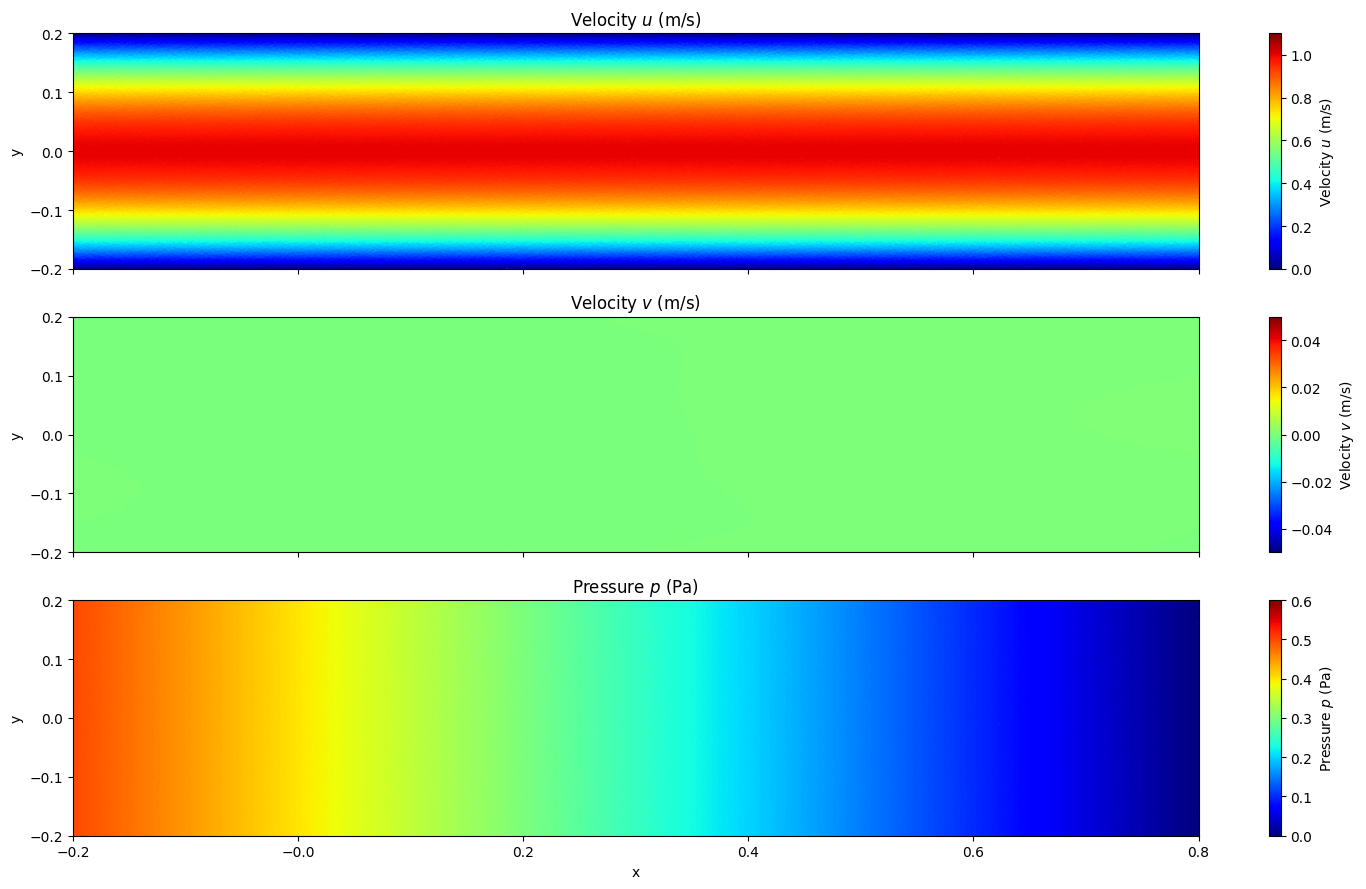

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Predict and plot results
samples = geom.random_points(500000)
result = model.predict(samples)

color_legend = [[0, 1.1], [-0.05, 0.05], [0, 0.6]]
magnituds = [f"Velocity $u$ (m/s)", f"Velocity $v$ (m/s)", f"Pressure $p$ (Pa)"]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 9), sharex=True)

xmin, xmax = samples[:, 0].min(), samples[:, 0].max()
ymin, ymax = samples[:, 1].min(), samples[:, 1].max()

for idx, ax in enumerate(axes):
    sc = ax.scatter(samples[:, 0], samples[:, 1], c=result[:, idx], cmap="jet", s=1)
    
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    ax.set_xticks(np.linspace(xmin, xmax, 6))
    ax.set_yticks(np.linspace(ymin, ymax, 5))
    
    ax.set_title(f"{magnituds[idx]}")
    ax.set_ylabel("y")
    
    sc.set_clim(color_legend[idx])

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(magnituds[idx])

axes[-1].set_xlabel("x")

plt.tight_layout()
plt.show()

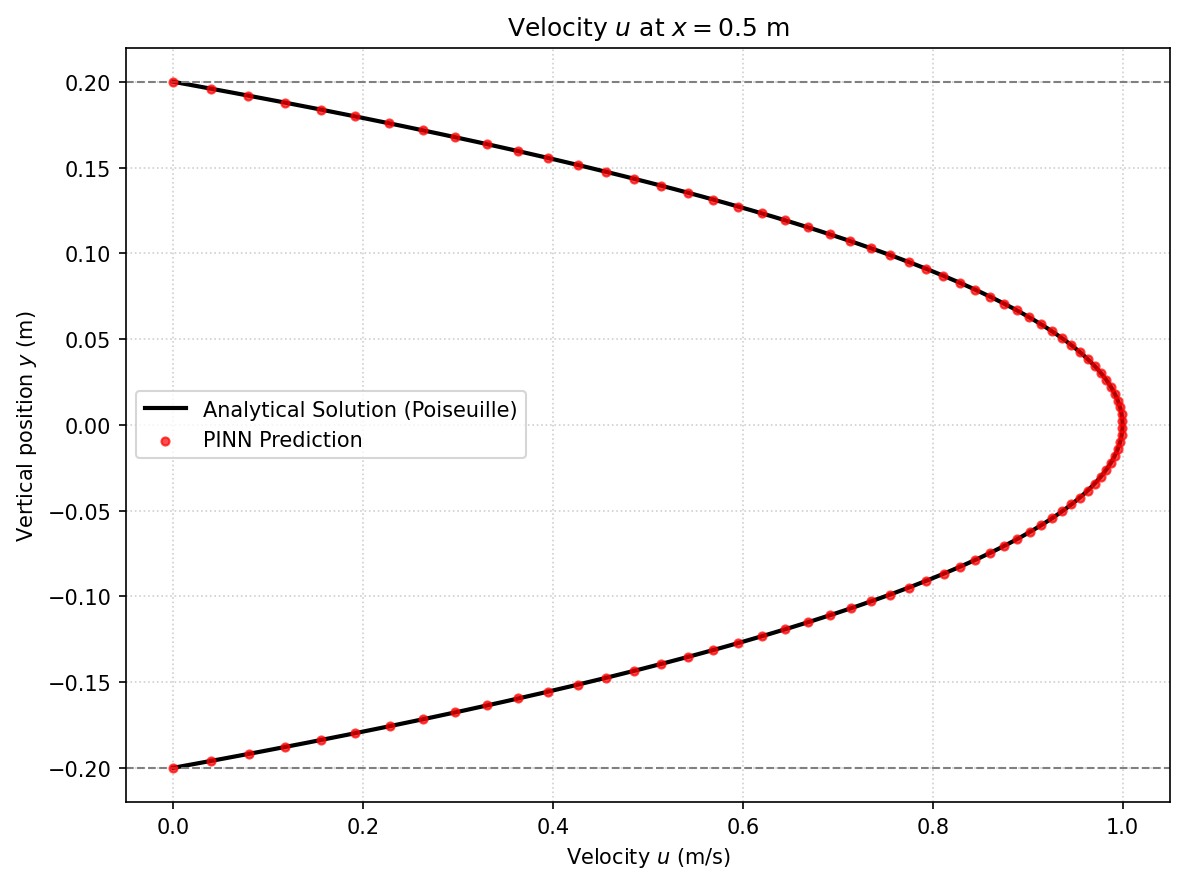

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

H = 0.4
u_max = 1.0
x_eval = 0.5
num_points = 100

y_eval = np.linspace(-H/2, H/2, num_points).reshape(-1, 1)

x_array = np.full_like(y_eval, x_eval)
X_test = np.hstack((x_array, y_eval))

u_pred = model.predict(X_test)[:, 0]

y_teoric = np.linspace(-H/2, H/2, 500)
u_teoric = u_max * (1 - (y_teoric / (H/2))**2)

plt.figure(figsize=(8, 6), dpi=150)

plt.plot(u_teoric, y_teoric, 'k-', linewidth=2, label='Analytical Solution (Poiseuille)')

plt.scatter(u_pred, y_eval, color='red', marker='o', s=15, alpha=0.7, label='PINN Prediction', zorder=5)

plt.axhline(-H/2, color='gray', linestyle='--', linewidth=1)
plt.axhline(H/2, color='gray', linestyle='--', linewidth=1)

plt.title(f'Velocity $u$ at $x = {x_eval}$ m')
plt.xlabel(f'Velocity $u$ (m/s)')
plt.ylabel(f'Vertical position $y$ (m)')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()